In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [67]:
#Прочитаем обработанные данные
X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')

y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

In [68]:
#Инициализируем функцию для подсчета метрик моделей
results = []

def evaluate_model(name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    results.append({
        'model': name,
        'accuracy': metrics.accuracy_score(y_test, y_pred),
        'precision': metrics.precision_score(y_test, y_pred),
        'f1': metrics.f1_score(y_test, y_pred),
        'roc_auc': metrics.roc_auc_score(y_test, y_proba)
    })

In [69]:
#Попробуем построить рандомный лес
#Инициализируем лес
rf = ensemble.RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    min_samples_leaf=5,
    max_depth=10,
    random_state=42
)
#Обучаем лес
rf.fit(X_train, y_train)
evaluate_model('RandomForest', rf, X_test, y_test)
#Делаем предсказание
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print('Accuracy:', round(metrics.accuracy_score(y_test, y_pred), 3))
print('Precision:', round(metrics.precision_score(y_test, y_pred), 3))
print('F1:', round(metrics.f1_score(y_test, y_pred), 3))
print('ROC-AUC:', round(metrics.roc_auc_score(y_test, y_proba), 3))

Accuracy: 0.692
Precision: 0.712
F1: 0.63
ROC-AUC: 0.746


Случайный лес справляется с задачей чуть лучше, чем модели в бейзлайне, попробуем градиентный бустинг

In [70]:
#Инициализируем градиентный бустинг
gb = ensemble.GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)
#Обучаем бустинг
gb.fit(X_train, y_train)
evaluate_model('Boosting', gb, X_test, y_test)
#Делаем предсказание
y_pred = gb.predict(X_test)
y_proba = gb.predict_proba(X_test)[:, 1]

print('Accuracy:', round(metrics.accuracy_score(y_test, y_pred), 3))
print('Precision:', round(metrics.precision_score(y_test, y_pred), 3))
print('F1:', round(metrics.f1_score(y_test, y_pred), 3))
print('ROC-AUC:', round(metrics.roc_auc_score(y_test, y_proba), 3))

Accuracy: 0.689
Precision: 0.704
F1: 0.627
ROC-AUC: 0.742


Roc_auc чуть хуже, попробуем стекинг с лог-регрессией и деревом решений, в качестве мета-модели возьмем логистическую регрессию

In [71]:
#Инициализируем регрессию
lr = LogisticRegression(
    solver='sag',
    random_state=42,
    max_iter=1000
)
#Инициализируем дерево
tree_model = tree.DecisionTreeClassifier(
    random_state=42,
    criterion='entropy'
)

In [72]:
#Делаем стэккинг с мета-моделью логистической регрессией
stack = ensemble.StackingClassifier(
    estimators=[
        ('lr', lr),
        ('tree', tree_model),
        ('gb', gb)
    ],
    final_estimator=LogisticRegression()
)
#Обучаем стеккинг
stack.fit(X_train, y_train)
evaluate_model('Stacking', stack, X_test, y_test)
#делаем предсказание
y_pred = stack.predict(X_test)
y_proba = stack.predict_proba(X_test)[:, 1]

print('Accuracy:', round(metrics.accuracy_score(y_test, y_pred), 3))
print('Precision:', round(metrics.precision_score(y_test, y_pred), 3))
print('F1:', round(metrics.f1_score(y_test, y_pred), 3))
print('ROC-AUC:', round(metrics.roc_auc_score(y_test, y_proba), 3))

Accuracy: 0.688
Precision: 0.694
F1: 0.633
ROC-AUC: 0.746


Немного лучше

Попробуем найти гиперпараметры с помощью ***optuna***

In [73]:
#Инициализируем функцию для поиска гиперпараметров
def optuna_rf(trial):
    #Задаем пространство гиперпараметров для оптимизации
    n_estimators = trial.suggest_int('n_estimators', 100, 200)
    max_depth = trial.suggest_int('max_depth', 10, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10)

    #Создаем модель RandomForest с параметрами из Optuna
    model = ensemble.RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    #Оценка модели с помощью кросс-валидации по метрике ROC-AUC
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    #Возвращаем среднее значение метрики
    return scores.mean()

In [74]:
#Создадим объект study с максимизацией заданной метрики (roc_auc)
study = optuna.create_study(direction='maximize')
#Запустим подбор 50 итераций
study.optimize(optuna_rf, n_trials=50)

In [75]:
#Выведем лучшие параметры
print(study.best_params)

{'n_estimators': 167, 'max_depth': 10, 'min_samples_leaf': 3}


In [76]:
#Создаем модель с подобранными параметрами
best_rf = ensemble.RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

#Обучаем модель
best_rf.fit(X_train, y_train)
#Заносим результаты
evaluate_model('best_rf', best_rf, X_test, y_test)
#Делаем предсказания
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print('Accuracy:', round(metrics.accuracy_score(y_test, y_pred), 3))
print('Precision:', round(metrics.precision_score(y_test, y_pred), 3))
print('F1:', round(metrics.f1_score(y_test, y_pred), 3))
print('ROC-AUC:', round(metrics.roc_auc_score(y_test, y_proba), 3))

Accuracy: 0.693
Precision: 0.71
F1: 0.631
ROC-AUC: 0.746


Оптимизированный лес справляется примерно так же как и стекинг, попробуем CatBoost

In [77]:
#Создаем модель с произвольными гиперпараметрами
cat = CatBoostClassifier(
    depth=6,
    learning_rate=0.05,
    iterations=500,
    random_state=42,
    verbose=False
)

#Обучаем модель
cat.fit(X_train, y_train)
#Заносим результаты
evaluate_model('CatBoost', cat, X_test, y_test)
#Делаем предсказания
pred = cat.predict(X_test)
y_proba = cat.predict_proba(X_test)[:, 1]

print('Accuracy:', round(metrics.accuracy_score(y_test, y_pred), 3))
print('Precision:', round(metrics.precision_score(y_test, y_pred), 3))
print('F1:', round(metrics.f1_score(y_test, y_pred), 3))
print('ROC-AUC:', round(metrics.roc_auc_score(y_test, y_proba), 3))

Accuracy: 0.693
Precision: 0.71
F1: 0.631
ROC-AUC: 0.744


Чуть хуже предыдущих моделей, теперь попробуем подобрать гиперпараметры

In [78]:
#Инициализируем функцию для поиска гиперпараметров
def objective(trial):
    #Задаем пространство гиперпараметров для оптимизации
    params = {
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 20),
        'random_state': 42,
        'verbose': False
    }
    #Создаем модель CatBoost с параметрами из Optuna
    model = CatBoostClassifier(**params)

    #Оценка модели с помощью кросс-валидации по метрике ROC-AUC
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    #Возвращаем среднее значение метрики
    return scores.mean()

In [79]:
#Создадим объект study с максимизацией заданной метрики (roc_auc)
study = optuna.create_study(direction='maximize')
#Запустим подбор 50 итераций
study.optimize(objective, n_trials=50)

In [80]:
#Смотрим подобранные параметры и метрику
print('Best params:', study.best_params)
print('Best ROC-AUC:', study.best_value)

Best params: {'depth': 7, 'learning_rate': 0.010160122218172725, 'iterations': 499, 'l2_leaf_reg': 1, 'min_data_in_leaf': 20}
Best ROC-AUC: 0.7532254835832791


In [81]:
#Создаем модель с подобранными гиперпараметрами
best_cat = CatBoostClassifier(
    **study.best_params,
    random_state=42,
    verbose=False,
    auto_class_weights="Balanced"
)

#Обучаем модель
best_cat.fit(X_train, y_train)
#Заносим результаты
evaluate_model('BestCat', best_cat, X_test, y_test)
#Делаем предсказание
y_pred = best_cat.predict(X_test)

In [82]:
#Результаты -> Data Frame
results_df = pd.DataFrame(results)
#Выводим результаты, сортируя по метрике ROC-AUC
results_df.round(3).sort_values(by='roc_auc', ascending=False)

,model,accuracy,precision,f1,roc_auc
5,BestCat,0.695,0.695,0.648,0.750
0,RandomForest,0.692,0.712,0.630,0.746
3,best_rf,0.693,0.710,0.631,0.746
2,Stacking,0.688,0.694,0.633,0.746
4,CatBoost,0.688,0.703,0.627,0.744
1,Boosting,0.689,0.704,0.627,0.742


Лучшая модель по метрике ROC-AUC ***CatBoost*** с подобранными гиперпараметрами, результат 0.750

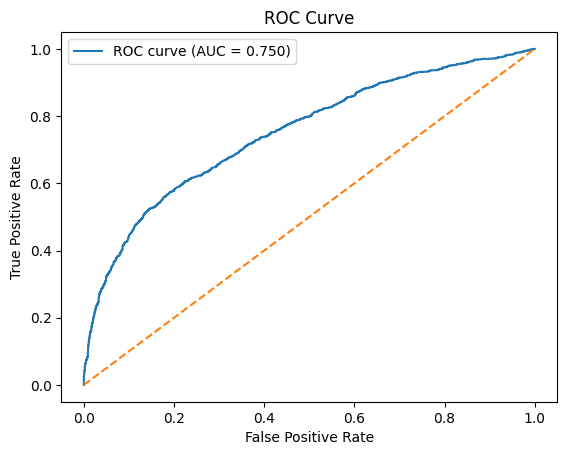

In [83]:
#Выведем ROC-кривую и сохраним в отдельную папку
y_proba = best_cat.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig("../images/roc_curve.png", bbox_inches="tight")

plt.show()